## CREDIT QUALITY & CUSTOMER PROFILING PROJECT

# 1. Import Libraries and Load Dataset

In [494]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import RocCurveDisplay
!pip install xgboost
!pip install -U scikit-learn
import xgboost as xgb
from xgboost import XGBClassifier

In [403]:
#Load dataset
df = pd.read_excel('/Users/hongyen/Desktop/PROJECT - YEN/Data/Credit Risk Dataset.xlsx')

# 2. Exploratory Data Analysis (EDA)

In [404]:
#Describe information from dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

Dataset contains 29 columns and 32.581 values

In [405]:
#Check null values
df.isnull().sum()

client_ID                        0
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
gender                           0
marital_status                   0
education_level                  0
country                          0
state                            0
city                             0
city_latitude                    0
city_longitude                   0
employment_type                  0
loan_term_months                 0
loan_to_income_ratio             0
other_debt                       0
debt_to_income_ratio             0
open_accounts                    0
credit_utilization_ratio         0
past_delinquencies  

In [406]:
df.duplicated().sum()

0

In [407]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,city_latitude,city_longitude,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,3.258100e+04,32581.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211,45.407613,-63.805473,38.501581,0.170553,1.156796e+04,0.345208,8.042018,0.499884,0.505141
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001,7.644809,46.615580,16.012441,0.107049,1.306093e+04,0.129406,4.328087,0.259530,0.711745
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000,29.760400,-123.365600,12.000000,0.000789,2.252074e+02,0.064502,0.000000,0.050001,0.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000,40.712800,-96.797000,24.000000,0.089655,5.387168e+03,0.251236,4.000000,0.275358,0.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000,46.813900,-75.697200,36.000000,0.148148,8.995071e+03,0.333188,8.000000,0.500289,0.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000,51.507400,-3.943600,60.000000,0.229167,1.456293e+04,0.423142,12.000000,0.725056,1.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000,55.953300,-0.127800,60.000000,0.830000,1.187999e+06,1.053888,15.000000,0.949998,6.000000


# Data Cleaning

In [408]:
#check percentage null vaules in dataset
null_percent = (df[['loan_int_rate','person_emp_length']].isnull().sum() / len(df[['loan_int_rate','person_emp_length']])) * 100

In [409]:
null_percent

loan_int_rate        9.563856
person_emp_length    2.747000
dtype: float64

In [410]:
null_data = df[df[['person_emp_length']].isnull().any(axis=1)]
null_data

,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
84,CUST_32472,53,54000,RENT,NaN,MEDICAL,D,10000,14.59,1,...,42.8864,-78.8784,Self-employed,60,0.185185,13590.647800,0.436864,11,0.105075,0
243,CUST_32329,51,18408,RENT,NaN,PERSONAL,C,1000,14.65,1,...,45.5017,-73.5673,Full-time,24,0.054324,1411.842476,0.131021,15,0.627551,3
264,CUST_32361,70,39996,RENT,NaN,MEDICAL,C,3600,15.23,0,...,48.4284,-123.3656,Part-time,36,0.090009,10462.430463,0.351596,12,0.280386,0
283,CUST_32454,56,32400,RENT,NaN,MEDICAL,A,8575,7.51,0,...,55.9533,-3.1883,Full-time,24,0.264660,8739.115541,0.534386,9,0.917754,1
680,CUST_29631,38,34000,OWN,NaN,HOMEIMPROVEMENT,C,11000,13.98,0,...,43.6532,-79.3832,Full-time,60,0.323529,1955.110584,0.381033,5,0.071916,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32576,CUST_12508,26,38400,OWN,NaN,HOMEIMPROVEMENT,B,7000,12.69,0,...,51.4816,-3.1791,Self-employed,60,0.182292,3920.400724,0.284385,13,0.813481,0
32577,CUST_14319,26,30000,RENT,NaN,VENTURE,A,14500,7.66,1,...,37.7749,-122.4194,Full-time,60,0.483333,3740.290424,0.608010,14,0.315347,1
32578,CUST_14910,26,120000,MORTGAGE,NaN,VENTURE,B,25000,12.69,0,...,34.0522,-118.2437,Full-time,60,0.208333,22476.374790,0.395636,11,0.751020,0
32579,CUST_17187,26,64000,RENT,NaN,DEBTCONSOLIDATION,B,1000,10.75,0,...,55.8642,-4.2518,Part-time,60,0.015625,7307.928473,0.129811,4,0.611709,0


=> delete null values person_emp_lenghth (2.74%) and fill missing values in loan_int_rate (9.56%)

In [411]:
#impute null values in loan_int_rate columns by filling the meadian interest based on loan grade & loan intent
df['loan_int'] = df['loan_int_rate'].fillna(
    df.groupby(['loan_grade', 'loan_intent'])['loan_int_rate'].transform('median'))

In [412]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender                      325

In [413]:
#drop loan_int_rate and null values in person_emp_length

df1 = df.dropna(subset=['person_emp_length'])
df1 = df1.drop('loan_int_rate', axis=1)


df1 = df1.reset_index(drop=True)

In [414]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31686 entries, 0 to 31685
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   31686 non-null  object 
 1   person_age                  31686 non-null  int64  
 2   person_income               31686 non-null  int64  
 3   person_home_ownership       31686 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 31686 non-null  object 
 6   loan_grade                  31686 non-null  object 
 7   loan_amnt                   31686 non-null  int64  
 8   loan_status                 31686 non-null  int64  
 9   loan_percent_income         31686 non-null  float64
 10  cb_person_default_on_file   31686 non-null  object 
 11  cb_person_cred_hist_length  31686 non-null  int64  
 12  gender                      31686 non-null  object 
 13  marital_status              316

In [415]:
#check duplicated values
df1.duplicated().sum()

0

### Check Outliers and Handle them

In [416]:
#check outliers 
df1.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_status,loan_percent_income,cb_person_cred_hist_length,city_latitude,city_longitude,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies,loan_int
count,31686.000000,3.168600e+04,31686.000000,31686.000000,31686.000000,31686.000000,31686.000000,31686.000000,31686.000000,31686.000000,31686.000000,3.168600e+04,31686.000000,31686.000000,31686.000000,31686.000000,31686.000000
mean,27.747302,6.669188e+04,4.789686,9661.337815,0.215426,0.169612,5.809316,45.408199,-63.745452,38.487786,0.169971,1.167403e+04,0.344591,8.037304,0.499748,0.505081,11.041946
std,6.360283,6.242729e+04,4.142630,6336.226458,0.411124,0.106297,4.060867,7.651618,46.615640,16.003728,0.106574,1.317124e+04,0.129033,4.327459,0.259302,0.711383,3.202121
min,20.000000,4.000000e+03,0.000000,500.000000,0.000000,0.000000,2.000000,29.760400,-123.365600,12.000000,0.000789,3.185199e+02,0.064502,0.000000,0.050001,0.000000,5.420000
25%,23.000000,3.939700e+04,2.000000,5000.000000,0.000000,0.090000,3.000000,40.712800,-96.797000,24.000000,0.089289,5.457214e+03,0.250847,4.000000,0.275430,0.000000,7.900000
50%,26.000000,5.600000e+04,4.000000,8000.000000,0.000000,0.150000,4.000000,46.813900,-75.697200,36.000000,0.147115,9.088971e+03,0.332694,8.000000,0.500063,0.000000,10.990000
75%,30.000000,8.000000e+04,7.000000,12500.000000,0.000000,0.230000,8.000000,51.507400,-3.943600,60.000000,0.228555,1.467710e+04,0.422488,12.000000,0.723907,1.000000,13.480000
max,144.000000,6.000000e+06,123.000000,35000.000000,1.000000,0.830000,30.000000,55.953300,-0.127800,60.000000,0.830000,1.187999e+06,1.053888,15.000000,0.949998,6.000000,23.220000


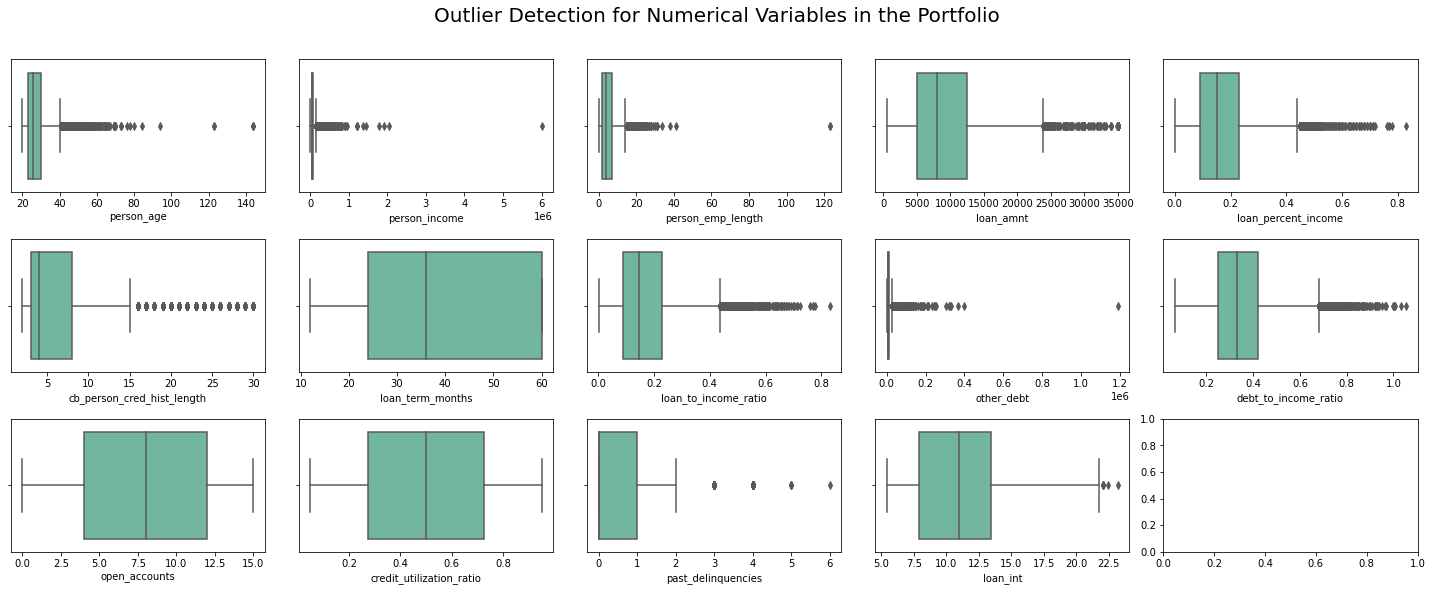

In [417]:
# 1. Check outliers for numerical columns
cols_num = [
    'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 
    'loan_percent_income', 'cb_person_cred_hist_length', 
    'loan_term_months', 'loan_to_income_ratio', 'other_debt', 
    'debt_to_income_ratio', 'open_accounts',
    'credit_utilization_ratio', 'past_delinquencies', 'loan_int'
]

# visualization by boxplot
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 8))
fig.suptitle('Outlier Detection for Numerical Variables in the Portfolio', fontsize=20, y=1.02)
axes_flat = axes.flatten()

for i, col in enumerate(cols_num):
    sns.boxplot(x=df1[col], ax=axes_flat[i], palette="Set2")
   

plt.tight_layout()
plt.show()

In [418]:
#create dataframe with condition is person age <100
df2 = df1[df1['person_age'] < 100]


In [419]:
#Create df3 from df2: emp_length does not exceed customer age minus 15
#Condition 1: emp_length < 60 years
#Condition 2: customer age ≥ 15 (eligible for work or educational loans)

df3 = df2[
    (df2['person_emp_length'] < 60) & 
    (df2['person_age'] - df2['person_emp_length'] >= 15)
]

# check result
print(f"df2 shape: {df2.shape}")
print(f"df3 shape: {df3.shape}")
print(f"error rows: {len(df2) - len(df3)}")

df2 shape: (31681, 29)
df3 shape: (31679, 29)
error rows: 2


### Check class imbalance in Target Varible (loan_status)

In [420]:
#calculated imbalance ratio in loan_status
loan_status_values = df3["loan_status"].value_counts()
loan_status_values

0    24854
1     6825
Name: loan_status, dtype: int64

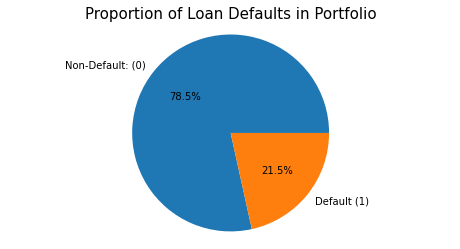

In [421]:
#visualization imbalance class in  loan status
labels = ['Non-Default: (0)', 'Default (1)']


plt.figure(figsize=(8, 4))
plt.pie(loan_status_values, 
        labels=labels,autopct='%1.1f%%') 

plt.title('Proportion of Loan Defaults in Portfolio', fontsize=15)
plt.axis('equal')  
plt.show()

### Use a pairplot to visualize the relationships between important variables

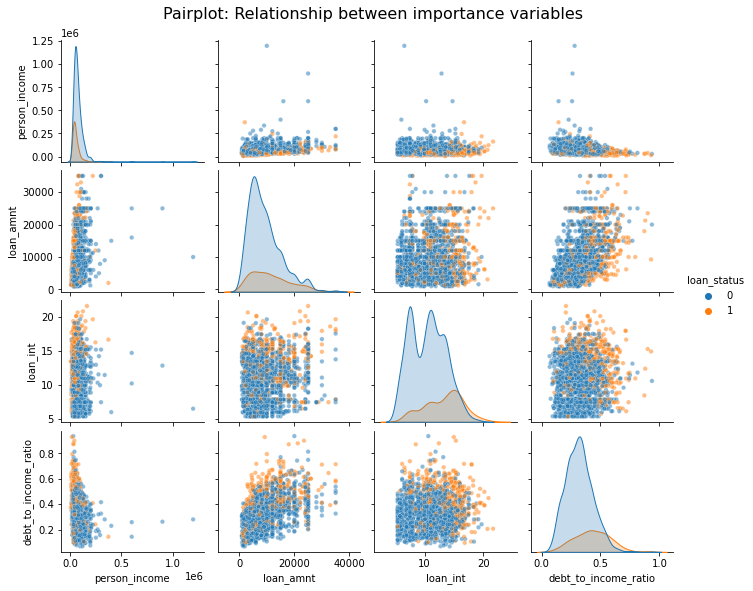

In [422]:
# 1.Only select the most important variables
important_numerical = [
    'person_income', 'loan_amnt', 'loan_int', 
   'debt_to_income_ratio'
]

# 2.Visualization Pairplot
sns.pairplot(
    df3[important_numerical + ['loan_status']].sample(n=2000, random_state=42, replace=True), 
    hue='loan_status', height = 2,aspect = 1.2,
    plot_kws={'alpha': 0.5, 's': 20} 
)

plt.suptitle('Pairplot: Relationship between importance variables', y=1.02, fontsize=16)
plt.show()

### Plot a matrix showing the correlation between numerical variables and the target variable

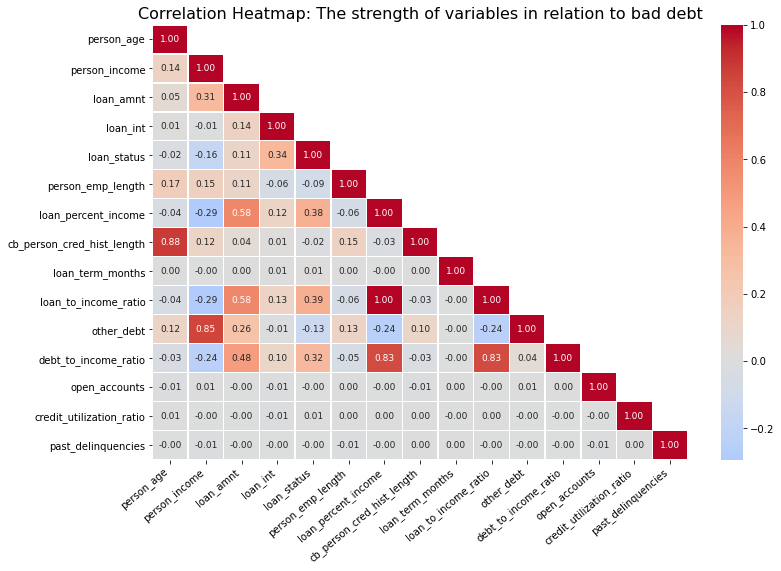

In [423]:
# Calculate the correlation matrix
num_cols = ['person_age', 'person_income','loan_amnt','loan_int','loan_status','person_emp_length',
            'loan_percent_income','cb_person_cred_hist_length','loan_term_months','loan_to_income_ratio',
            'other_debt','debt_to_income_ratio','open_accounts','credit_utilization_ratio','past_delinquencies']
corr_matrix = df3[num_cols].corr()

# Correlation Heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
plt.figure(figsize=(12, 8)) 
sns.heatmap(corr_matrix, 
            mask=mask,          
            annot=True,         
            fmt='.2f',           
            cmap='coolwarm',       
            center=0,  
            linewidths=0.5,
            annot_kws={"size": 9})

plt.title('Correlation Heatmap: The strength of variables in relation to bad debt', fontsize=16)
plt.xticks(rotation=40, ha='right')
plt.show()

### Analyze categorical variables in relation to the target variable

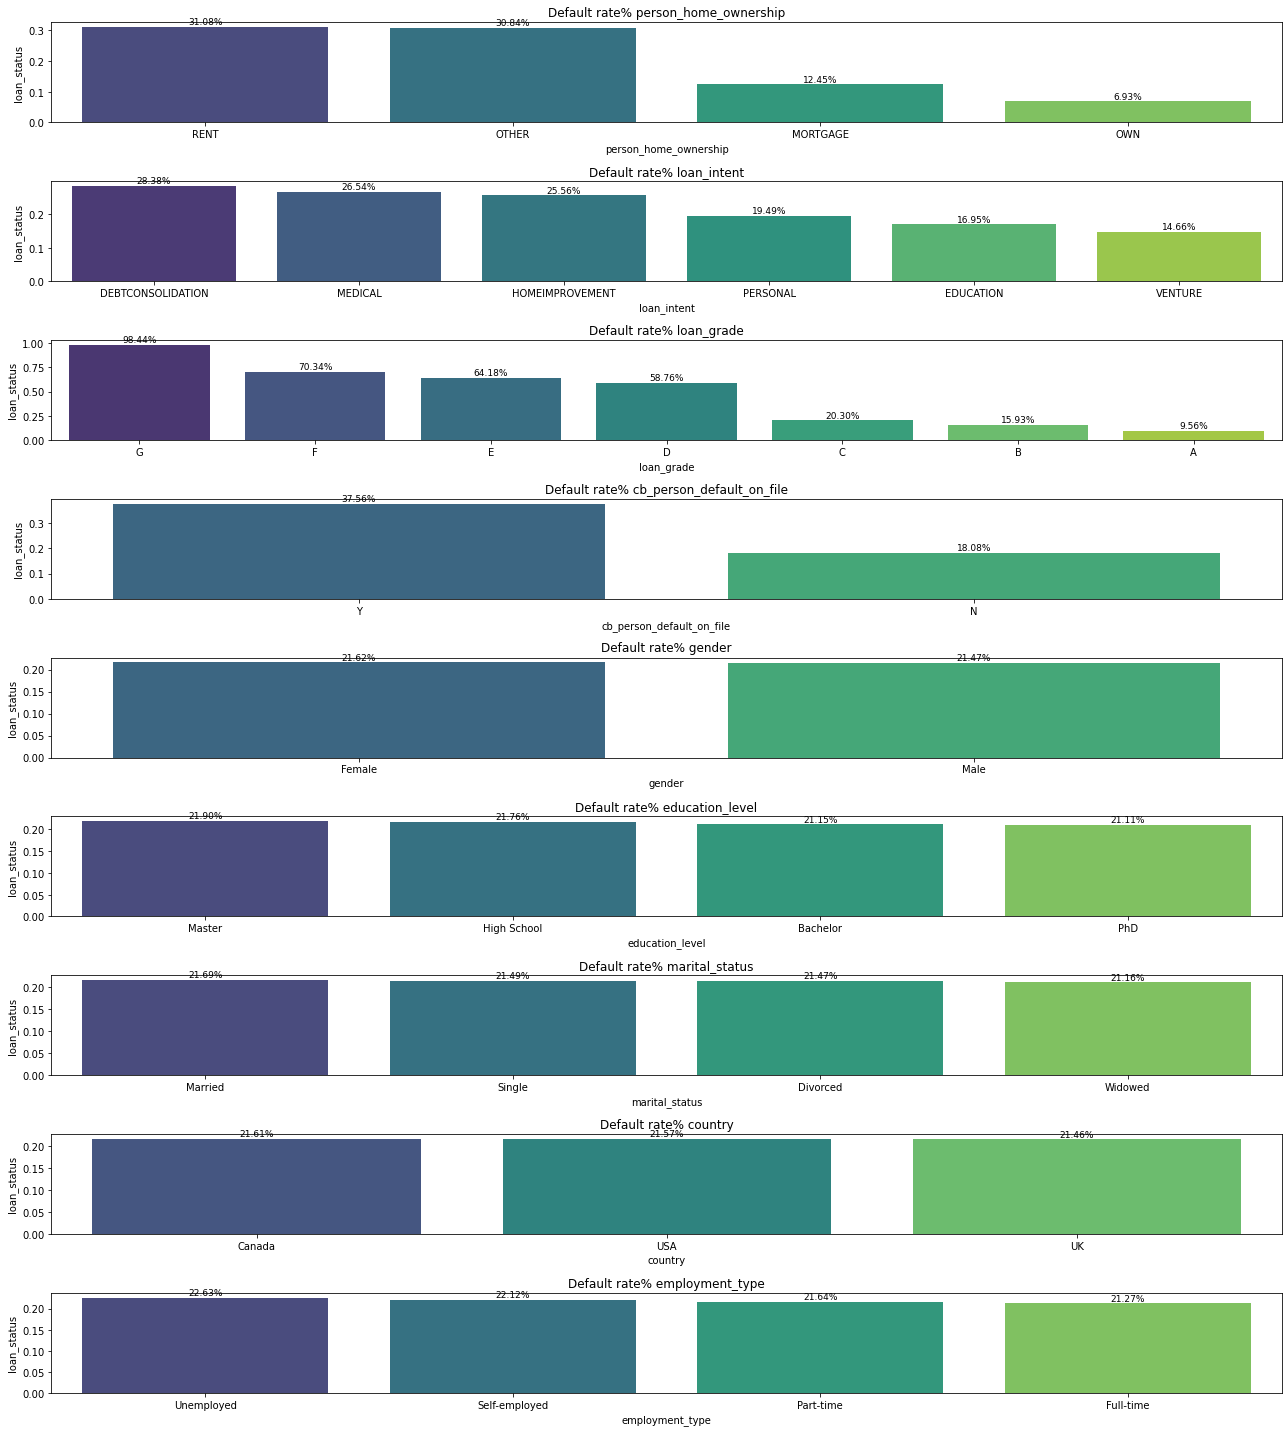

In [424]:
#Analyze categorical variables

cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade','cb_person_default_on_file','gender',
            'education_level','marital_status','country','employment_type']

# visualization 
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(18, 20))


for i, col in enumerate(cat_cols):
   
    order = df3.groupby(col)['loan_status'].mean().sort_values(ascending=False).index
    sns.barplot(ax=axes[i], x=col, y='loan_status', data=df3, order=order, palette='viridis', ci=None)
    axes[i].set_title(f'Default rate% {col}', fontsize=12)
    
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2%}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                         textcoords='offset points')
plt.tight_layout()
plt.show()

## 3. Data processing & Feature Engineering

### Encoding Categorical Variables

In [425]:
# 1.define (Mapping)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
edu_map = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
cb_person_default_on_file_map = {'Y': 1, 'N': 0}

# 2. copy dataframe
df_pre_model = df3.copy()

# 3. Ordinal Encoding
df_pre_model['loan_grade'] = df_pre_model['loan_grade'].map(grade_map)
df_pre_model['education_level'] = df_pre_model['education_level'].map(edu_map)
df_pre_model['cb_person_default_on_file'] = df_pre_model['cb_person_default_on_file'].map(cb_person_default_on_file_map)

# 4. One-Hot Encoding 
nom_cols = [
    'person_home_ownership', 'loan_intent', 'gender', 
    'marital_status', 'employment_type', 'country'
]

df_pre_model = pd.get_dummies(df_pre_model, columns=nom_cols, drop_first=True)

# 5. Check remained columns

remaining_objects = df_pre_model.select_dtypes(include=['object']).columns.tolist()
print(remaining_objects)

# 6. Check NaN 
print("\n--- check values ---")
print(df_pre_model[['loan_grade', 'education_level', 'cb_person_default_on_file']].isnull().sum())

['client_ID', 'state', 'city']

--- check values ---
loan_grade                   0
education_level              0
cb_person_default_on_file    0
dtype: int64


In [426]:
# delete unrelavant columns in pre-processing
cols_to_drop = ['client_ID', 'state', 'city', 'city_latitude', 'city_longitude','loan_percent_income']
df_model = df_pre_model.drop(columns=cols_to_drop, axis =1)

In [427]:
df_model = df_model.reset_index(drop=True)
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31679 entries, 0 to 31678
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   person_age                     31679 non-null  int64  
 1   person_income                  31679 non-null  int64  
 2   person_emp_length              31679 non-null  float64
 3   loan_grade                     31679 non-null  int64  
 4   loan_amnt                      31679 non-null  int64  
 5   loan_status                    31679 non-null  int64  
 6   cb_person_default_on_file      31679 non-null  int64  
 7   cb_person_cred_hist_length     31679 non-null  int64  
 8   education_level                31679 non-null  int64  
 9   loan_term_months               31679 non-null  int64  
 10  loan_to_income_ratio           31679 non-null  float64
 11  other_debt                     31679 non-null  float64
 12  debt_to_income_ratio           31679 non-null 

In [428]:
df_model.isnull().sum()

person_age                       0
person_income                    0
person_emp_length                0
loan_grade                       0
loan_amnt                        0
loan_status                      0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
education_level                  0
loan_term_months                 0
loan_to_income_ratio             0
other_debt                       0
debt_to_income_ratio             0
open_accounts                    0
credit_utilization_ratio         0
past_delinquencies               0
loan_int                         0
person_home_ownership_OTHER      0
person_home_ownership_OWN        0
person_home_ownership_RENT       0
loan_intent_EDUCATION            0
loan_intent_HOMEIMPROVEMENT      0
loan_intent_MEDICAL              0
loan_intent_PERSONAL             0
loan_intent_VENTURE              0
gender_Male                      0
marital_status_Married           0
marital_status_Single            0
marital_status_Widow

## 4. MODELING

## Model selection

### Scaling dataset

In [429]:
# 1. create X, y
X = df_model.drop('loan_status', axis=1)
y = df_model['loan_status']

# 2. split Train/Test (80/20) - stratify 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model 1: Logistic Regression (LR) 

In [430]:
print("--- LOGISTIC REGRESSION RESULT ---")
model_LR = LogisticRegression(max_iter=1000, random_state = 42)
model_LR.fit(X_train_scaled, y_train)
y_pred_LR = model_LR.predict(X_test_scaled)

print(classification_report(y_test, y_pred_LR))

--- LOGISTIC REGRESSION RESULT ---
              precision    recall  f1-score   support

           0       0.87      0.95      0.91      4971
           1       0.72      0.49      0.58      1365

    accuracy                           0.85      6336
   macro avg       0.80      0.72      0.74      6336
weighted avg       0.84      0.85      0.84      6336



=> mutil-corr variables and imbalanced class in target variable (loan_status)

In [431]:
#handle imbalanced dataset using class_weight
model_LR_balanced = LogisticRegression(max_iter=1000,class_weight ='balanced', random_state = 42)
model_LR_balanced.fit(X_train_scaled, y_train)

y_pred_bal_LR = model_LR_balanced.predict(X_test_scaled)
print(classification_report(y_test, y_pred_bal_LR))

              precision    recall  f1-score   support

           0       0.92      0.80      0.85      4971
           1       0.50      0.76      0.61      1365

    accuracy                           0.79      6336
   macro avg       0.71      0.78      0.73      6336
weighted avg       0.83      0.79      0.80      6336



=> the model suffers from multicollinearity among variables, so it is not used.

### Model 2: Random Forest (RF) - Baseline

In [432]:
model_RF = RandomForestClassifier(n_estimators=500, 
                                  class_weight='balanced', max_depth = 6,
                                  random_state=42)

model_RF.fit(X_train_scaled, y_train)

y_pred_rf = model_RF.predict(X_test_scaled)

print('RANDOM FOREST RESULT')
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULT
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      4971
           1       0.66      0.75      0.70      1365

    accuracy                           0.86      6336
   macro avg       0.79      0.82      0.81      6336
weighted avg       0.87      0.86      0.87      6336



### Model 3: XGBoost (Extreme Gradient Boosting)

In [433]:
# 1. Calculate the ratio to balance the classes 
# Ratio = SUM (0) / SUM(1)
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 2. Create model XGBoost
model_xgb= XGBClassifier(
    n_estimators=100,
    scale_pos_weight=ratio, 
    random_state=42,
    eval_metric='logloss'
)

# 3. Train model 
model_xgb.fit(X_train_scaled, y_train)

# 4. Predict
y_pred_xgb = model_xgb.predict(X_test_scaled)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4971
           1       0.86      0.75      0.80      1365

    accuracy                           0.92      6336
   macro avg       0.90      0.86      0.88      6336
weighted avg       0.92      0.92      0.92      6336



In [434]:
###SUMMARY RESULT


def get_stats(y_pred, name):
    return {
        'Model': name,
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
       
    }

# 2. 
results = [
    get_stats(y_pred_LR, "Logistic Regression"),
    get_stats(y_pred_bal_LR, "Logistic Regression - Balanced"),
    get_stats(y_pred_rf, "Random Forest"),
    get_stats(y_pred_xgb, "XGBoost Baseline")
]

# 3.print summary dataframe
df_summary = pd.DataFrame(results).round(2)
display(df_summary)

,Model,Precision,Recall,F1-Score
0,Logistic Regression,0.72,0.49,0.58
1,Logistic Regression - Balanced,0.50,0.76,0.61
2,Random Forest,0.66,0.75,0.70
3,XGBoost Baseline,0.86,0.75,0.80


### EVALUATE MODEL

### ROC Curve (Receiver Operating Characteristic Curve) 

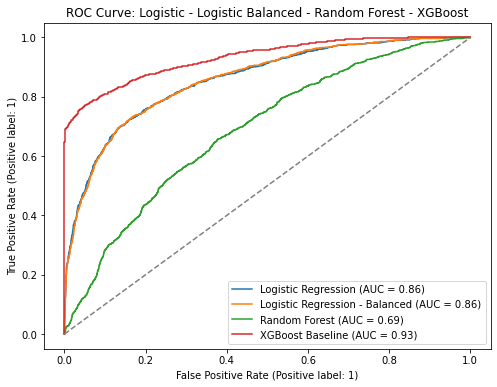

In [491]:
# create figure

fig, ax = plt.subplots(figsize=(8, 6))

# ROC Curve for Logistic Regression -  (Scaled)

plot_roc_curve(model_LR, X_test_scaled, y_test, ax=ax, name='Logistic Regression')

# ROC Curve for Logistic Regression - balanced (Scaled)

plot_roc_curve(model_LR_balanced, X_test_scaled, y_test, ax=ax, name='Logistic Regression - Balanced')


#Random Forest-balanced 

plot_roc_curve(model_RF, X_test, y_test, ax=ax, name='Random Forest')

#XGboost baseline

plot_roc_curve(model_xgb, X_test_scaled, y_test, ax=ax, name='XGBoost Baseline')



ax.set_title('ROC Curve: Logistic - Logistic Balanced - Random Forest - XGBoost')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.show()

=>chose XGBoost Baseline

### Confusion Matrix

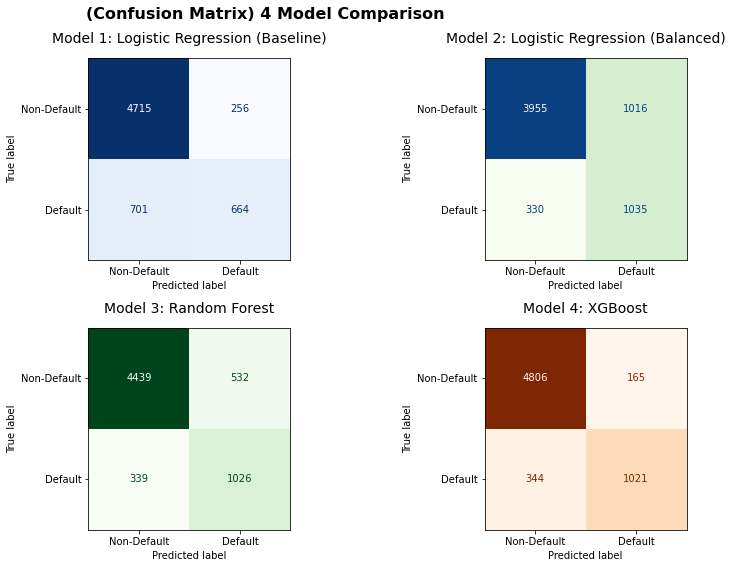

In [509]:
# 1. calculated confusion matrix
cm_LR = confusion_matrix(y_test, y_pred_LR)
cm_LR_bal = confusion_matrix(y_test, y_pred_bal_LR)
cm_RF = confusion_matrix(y_test, y_pred_rf)
cm_XGB = confusion_matrix(y_test,  y_pred_xgb)

# 2. Create figure Layout 2x2
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# create list
cms = [cm_LR, cm_LR_bal, cm_RF, cm_XGB]
titles = [
    'Model 1: Logistic Regression (Baseline)', 
    'Model 2: Logistic Regression (Balanced)', 
    'Model 3: Random Forest', 
    'Model 4: XGBoost'
]
cmaps = ['Blues', 'GnBu', 'Greens', 'Oranges']

# 3 ConfusionMatrixDisplay
for i, ad in enumerate(ax.flat):
    disp = ConfusionMatrixDisplay(confusion_matrix=cms[i], display_labels=['Non-Default', 'Default'])
    
    
    disp.plot(ax=ad, cmap=cmaps[i], values_format='d')
    ad.set_title(titles[i], fontsize=14, pad=15)

    ad.images[0].colorbar.remove() 

plt.suptitle('(Confusion Matrix) 4 Model Comparison', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

### FEATURE IMPORTANCE

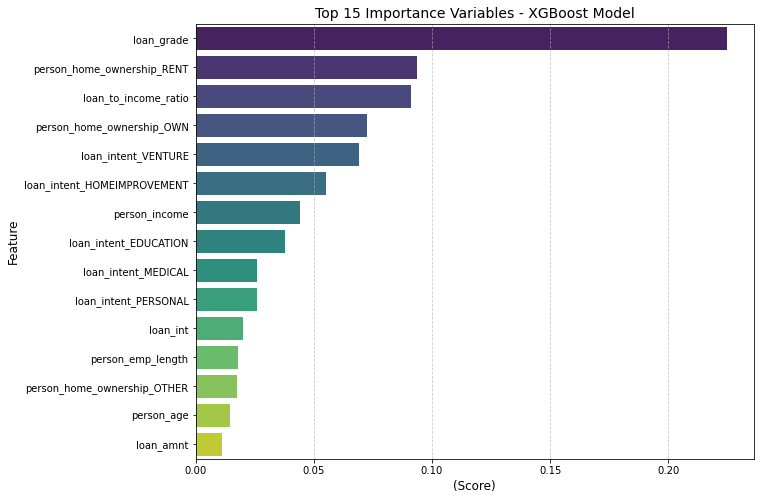

In [437]:
# 1. importance model_xgb
importances = model_xgb.feature_importances_
feature_names = X.columns 

# 2. create DataFrame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3.plot
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='viridis')

plt.title('Top 15 Importance Variables - XGBoost Model', fontsize=14)
plt.xlabel('(Score)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [438]:
# DOWNLOAD CLEANED DATASET
df_final = df3.copy()

In [439]:
# 1.download 
file_name = 'Credit Risk Dataset Cleaned.xlsx'

# 2
df_final.to_excel(file_name, index=False, engine='openpyxl')

In [440]:
#Visualization df3 Histogram to show percentile of income and age's customer, support insight in My SQL

In [441]:
p25_income = df3['person_income'].quantile(0.25)
p50_income = df3['person_income'].median()
p75_income= df3['person_income'].quantile(0.75)

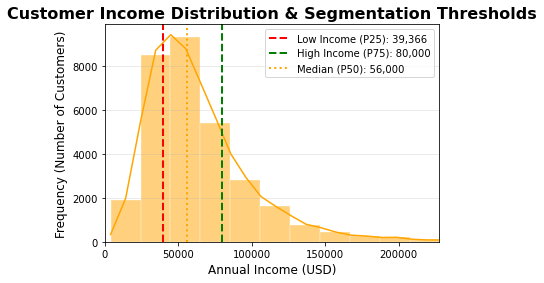

In [442]:
sns.histplot(df3['person_income'], bins=100, kde=True, color='orange', edgecolor='white')
plt.axvline(p25_income, color='red', linestyle='--', linewidth=2, label=f'Low Income (P25): {p25_income:,.0f}')
plt.axvline(p75_income, color='green', linestyle='--', linewidth=2, label=f'High Income (P75): {p75_income:,.0f}')
plt.axvline(p50_income, color='orange', linestyle=':', linewidth=2, label=f'Median (P50): {p50_income:,.0f}')

plt.title('Customer Income Distribution & Segmentation Thresholds', fontsize=16, fontweight='bold')
plt.xlabel('Annual Income (USD)', fontsize=12)
plt.ylabel('Frequency (Number of Customers)', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend()


plt.xlim(0, df3['person_income'].quantile(0.99)) 

plt.show()

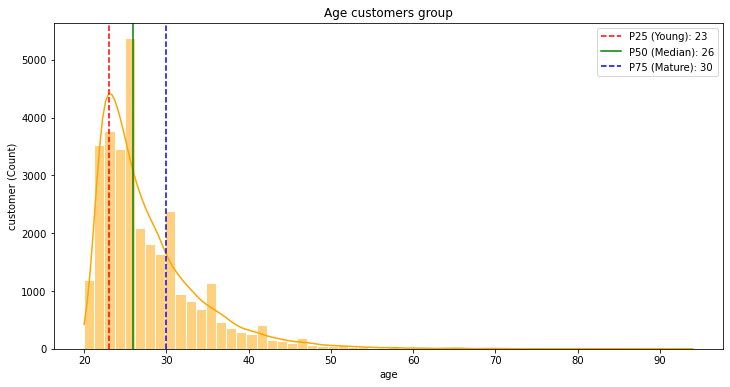

P25: 23.0, Median: 26.0, P75: 30.0


In [443]:
# 1. (Quartiles) for Age
age_stats = df['person_age'].describe(percentiles=[0.25, 0.5, 0.75])
p25 = age_stats['25%']
p50 = age_stats['50%'] # Median
p75 = age_stats['75%']

# 2.  Histogram 
plt.figure(figsize=(12, 6))

# bins=30: 
sns.histplot(df3['person_age'], bins=60, kde=True, color='orange', edgecolor='white')

# line P25, P50, P75
plt.axvline(p25, color='red', linestyle='--', label=f'P25 (Young): {p25:.0f}')
plt.axvline(p50, color='green', linestyle='-', label=f'P50 (Median): {p50:.0f}')
plt.axvline(p75, color='blue', linestyle='--', label=f'P75 (Mature): {p75:.0f}')

plt.title('Age customers group')
plt.xlabel('age')
plt.ylabel('customer (Count)')
plt.legend()
plt.show()

# I
print(f"P25: {p25}, Median: {p50}, P75: {p75}")